# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv). 

### Step 3. Assign it to a variable called chipo.

In [54]:
chipo=pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv',sep='\t')
chipo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   order_id            4622 non-null   int64
 1   quantity            4622 non-null   int64
 2   item_name           4622 non-null   str  
 3   choice_description  3376 non-null   str  
 4   item_price          4622 non-null   str  
dtypes: int64(2), str(3)
memory usage: 180.7 KB


### Step 4. See the first 10 entries

In [55]:
chipo.head()
#order_id :foreign key

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


### Step 5. Create a histogram of the top 5 items bought

<class 'pandas.Series'>


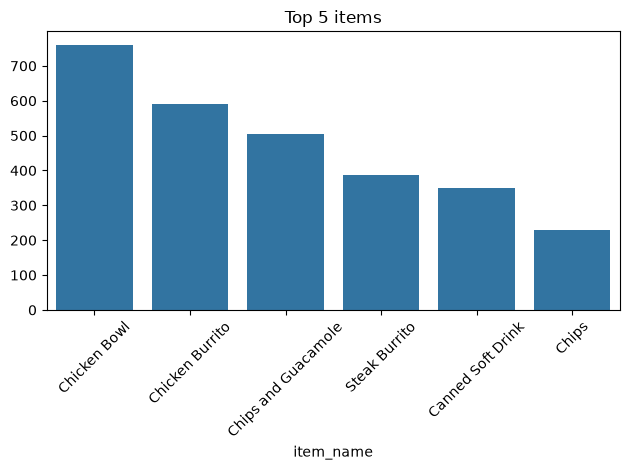

In [56]:
grouped=chipo.groupby('item_name')['quantity'].sum() #returns pandas.Series
print(type(grouped))
# grouped.sort_values(by='quantitiy',drop=True)
series=grouped.sort_values(ascending=False)[:6]

##data visualization
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

plt.title('Top 5 items')
sns.barplot(x=series.index,y=series.values)

plt.xticks(rotation=45)
plt.yticks()

plt.tight_layout()
plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

order_id
1       4
2       2
3       2
4       2
5       2
       ..
1830    2
1831    3
1832    2
1833    2
1834    3
Name: quantity, Length: 1834, dtype: int64


<Axes: xlabel='item_price', ylabel='quantity'>

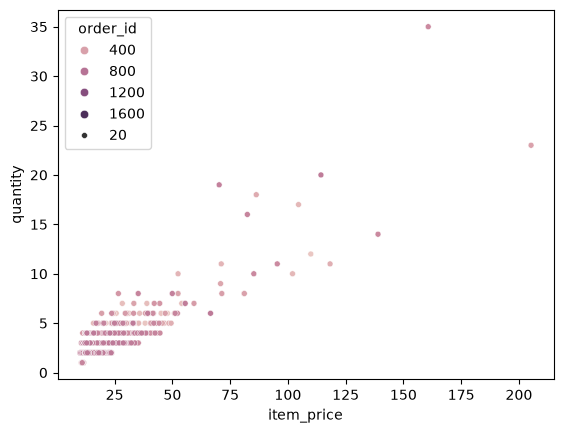

In [74]:
#deleting values of item price feature that begin with dollar sign
# chipo.item_price=pd.Series([float(val[1:]) for val in chipo.item_price])
# chipo

totalItemPrice=chipo.groupby(['order_id'])['item_price'].sum()
# print(totalItemPrice)

totalQuantity=chipo.groupby(['order_id'])['quantity'].sum()
print(totalQuantity)

import seaborn as sns

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=totalItemPrice,y=totalQuantity,size=20,hue=chipo.order_id)